In [ ]:
#Import library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import tensorflow as tf
from tqdm import tqdm
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.applications.xception import preprocess_input
from sklearn.utils import shuffle
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from google.colab import files
import cv2
from google.colab.patches import cv2_imshow
from sklearn.metrics import accuracy_score#Import data dari google drive
from google.colab import drive
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from sklearn.utils import shuffle
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

**Data Preparation**

In [ ]:
drive.mount('drive', force_remount=True)

Mounted at drive


In [ ]:
data_dir = '/content/drive/MyDrive/Shoes Dataset'
test_dir = '/content/drive/MyDrive/Shoes Test'

In [ ]:
# Mengecek folder dari file Test dan mengurutkannya berdasarkan alfabet
folders = os.listdir(data_dir)
folders.sort()  # Mengurutkan folder berdasarkan urutan alfabet

# Tampilkan daftar folder yang telah diurutkan
print(folders)

['Boat', 'Brogue', 'Clog', 'Sneaker']


In [ ]:
#Pelabelan data
label_code = {'Boat': 0 , 'Clog' : 1, 'Brogue' : 2, 'Sneaker' : 3}
label_decode = ['Sepatu Formal', 'Sendal Santai', 'Sepatu Santai', 'Sepatu Kasual']

In [ ]:
#Menghitung jumlah data
i = 0
for dirname, _, filenames in os.walk('/content/drive/MyDrive/Shoes Dataset'):
    for filename in filenames:
        i += 1
print(i)

10718


In [ ]:
# Set constants
IMG_WIDTH = 299
IMG_HEIGHT = 299
IMG_CHANNELS = 3
CATEGORIES = 4

**PREPROCESSING**

In [ ]:
# Pre-processing data
i = 0

# Pembuatan data generator
image_datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True)

In [ ]:
#Pre-processing data Train dan Val
X_train = []
y_train = []

for dirname, _, filenames in os.walk(data_dir):
    for filename in filenames:
        _path = os.path.join(dirname, filename)
        _img = load_img(_path, color_mode="rgb", target_size=(IMG_HEIGHT, IMG_WIDTH)) #Resize dan mode warna
        _img = img_to_array(_img) # ubah gambar ke array
        _img = preprocess_input(_img)  # preprocess xception
        X_train.append(_img)

        _label = dirname.split('/')[-1]
        _index = label_code[_label]
        y = [0] * CATEGORIES # memasukkan kedalam pelabelan
        y[_index] = 1
        y_train.append(y)
        i += 1

In [ ]:
#Pre-processing data Test
X_test = []
y_test = []

for dirname, _, filenames in os.walk(test_dir):
    for filename in filenames:
        _path = os.path.join(dirname, filename)
        _img = load_img(_path, color_mode="rgb", target_size=(IMG_HEIGHT, IMG_WIDTH))
        _img = img_to_array(_img)
        _img = preprocess_input(_img)
        X_test.append(_img)

        _label = dirname.split('/')[-1]
        _index = label_code[_label]

        y = [0] * CATEGORIES
        y[_index] = 1
        y_test.append(y)

# Konversi ke numpy arrays
X_test = np.array(X_test)
y_test = np.array(y_test)

print("Test data:", X_test.shape, y_test.shape)

Test data: (400, 299, 299, 3) (400, 4)


In [ ]:
#Menghitung jumlah dataset
train_counts = pd.Series(np.argmax(y_train, axis=1)).value_counts().sort_index()
test_counts = pd.Series(np.argmax(y_test, axis=1)).value_counts().sort_index()

train_counts.index = label_decode
test_counts.index = label_decode

print("Train:\n\n", train_counts)
print("\nTest:\n\n", test_counts)

Train:

 Sepatu Formal    2636
Sendal Santai    2824
Sepatu Santai    2592
Sepatu Kasual    2666
Name: count, dtype: int64

Test:

 Sepatu Formal    100
Sendal Santai    100
Sepatu Santai    100
Sepatu Kasual    100
Name: count, dtype: int64


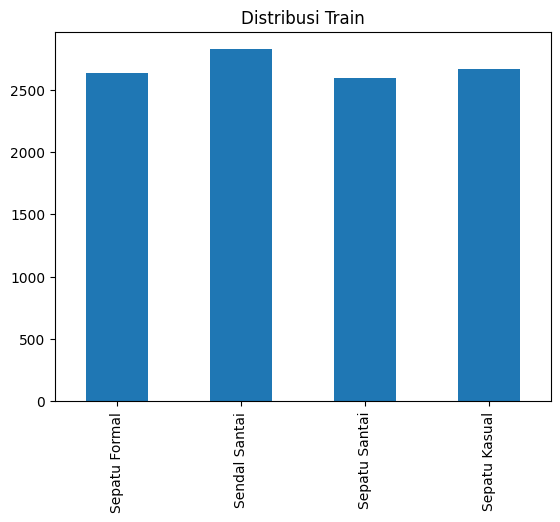

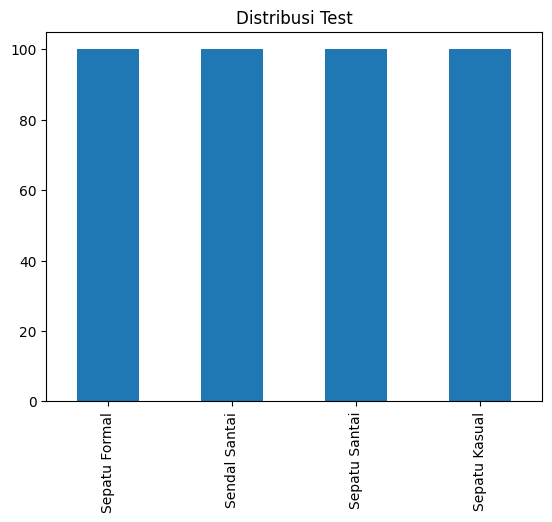

In [ ]:
#Visualisasi pembagian dataset
train_counts.plot(kind='bar', title='Distribusi Train')
plt.show()

test_counts.plot(kind='bar', title='Distribusi Test')
plt.show()

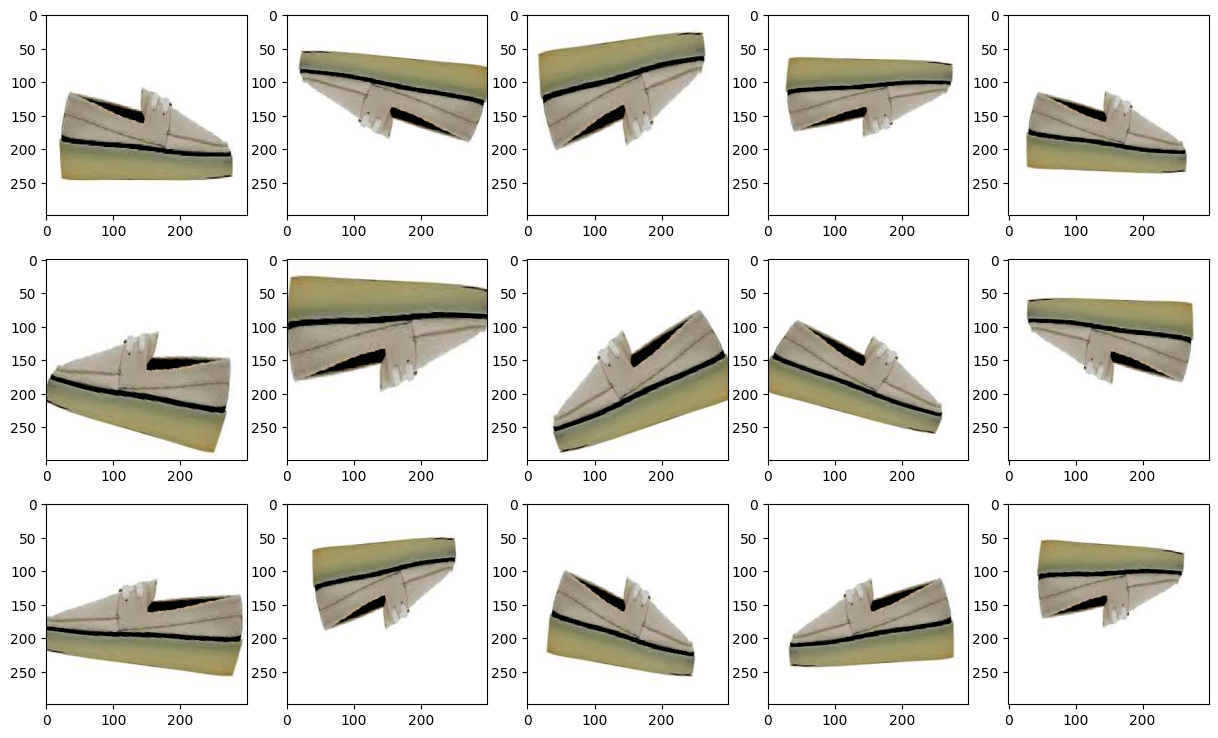

In [ ]:
# Visualize augmented images
augmented_images = []
num_rows = 3  # Number of rows
num_cols = 5  # Number of columns

for i in range(num_rows * num_cols):
    if i == 0:
        augmented_image = X_train[15]  # Use the original image for the first subplot
    else:
        augmented_image = image_datagen.random_transform(X_train[15])
    augmented_images.append(augmented_image)

# Display the augmented images with labels in a grid
plt.figure(figsize=(15, 9))
for i in range(num_rows):
    for j in range(num_cols):
        plt.subplot(num_rows, num_cols, i * num_cols + j + 1)
        plt.imshow(augmented_images[i * num_cols + j])
        plt.axis()
plt.show()

In [ ]:
#Inisialisasi data train
X_train = np.array(X_train)
y_train = np.array(y_train)

In [ ]:
# Pembagian data train dan val dengan size 8:2
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2)

In [ ]:
# Import Transfer Lear model with imagenet weights
base_model = tf.keras.applications.InceptionV3(weights='imagenet', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3), include_top=False)

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [ ]:
#Membuat model dapat di train
base_model.trainable = True

In [ ]:
# Create a new model
inputs = tf.keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))
x = base_model(inputs)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
x = tf.keras.layers.Dense(256, activation='relu')(x)
x = tf.keras.layers.Dropout(0.2)(x)

# Pass the extracted features through the remaining layers
outputs = tf.keras.layers.Dense(4, activation='softmax')(x)

# Create the final model
model = tf.keras.Model(inputs=inputs, outputs=outputs)

In [ ]:
# Check the model summary
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 8, 8, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,328,356 (85.18 MB)

 Trainable params: 22,293,924 (85.04 MB)

 Non-trainable params: 34,432 (134.50 KB)

In [ ]:
# Compile the model
model.compile(loss='categorical_crossentropy', optimizer=tf.keras.optimizers.Adam(), metrics=['accuracy'])

In [ ]:
#Memasukkan data train ke data generator
train_gen = image_datagen.flow(X_train, y_train, batch_size=32)

In [ ]:
# Fit the model
hist = model.fit(train_gen, validation_data=(X_val, y_val), epochs=20)

Epoch 1/20
268/268 ━━━━━━━━━━━━━━━━━━━━ 298s 793ms/step - accuracy: 0.6214 - loss: 0.9632 - val_accuracy: 0.5732 - val_loss: 1.3283
Epoch 2/20
268/268 ━━━━━━━━━━━━━━━━━━━━ 155s 577ms/step - accuracy: 0.7193 - loss: 0.7418 - val_accuracy: 0.6758 - val_loss: 0.8305
Epoch 3/20
268/268 ━━━━━━━━━━━━━━━━━━━━ 154s 575ms/step - accuracy: 0.7743 - loss: 0.6237 - val_accuracy: 0.6381 - val_loss: 1.0238
Epoch 4/20
268/268 ━━━━━━━━━━━━━━━━━━━━ 154s 575ms/step - accuracy: 0.7971 - loss: 0.5675 - val_accuracy: 0.6395 - val_loss: 0.9524
Epoch 5/20
268/268 ━━━━━━━━━━━━━━━━━━━━ 157s 584ms/step - accuracy: 0.8073 - loss: 0.5291 - val_accuracy: 0.6665 - val_loss: 0.9202
Epoch 6/20
268/268 ━━━━━━━━━━━━━━━━━━━━ 155s 577ms/step - accuracy: 0.8170 - loss: 0.5071 - val_accuracy: 0.8069 - val_loss: 0.5702
Epoch 7/20
268/268 ━━━━━━━━━━━━━━━━━━━━ 156s 580ms/step - accuracy: 0.8316 - loss: 0.4735 - val_accuracy: 0.7584 - val_loss: 0.6801
Epoch 8/20
268/268 ━━━━━━━━━━━━━━━━━━━━ 152s 566ms/step - accuracy: 0.8339 -

**Hasil**

In [ ]:
model.evaluate(X_test, y_test, batch_size=32)

13/13 ━━━━━━━━━━━━━━━━━━━━ 16s 699ms/step - accuracy: 0.8275 - loss: 0.5231


[0.5230810046195984, 0.8274999856948853]

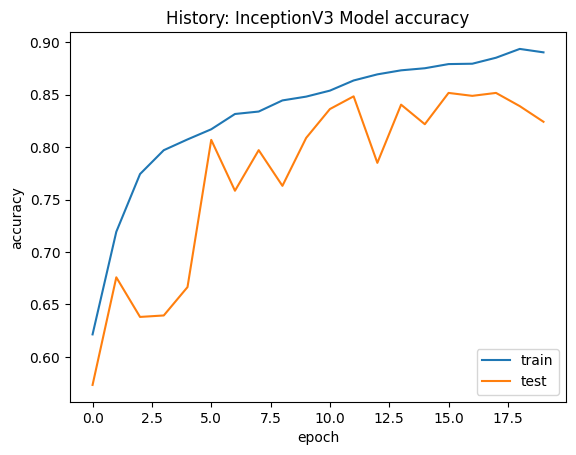

In [ ]:
#Diagram akurasi Model
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('History: InceptionV3 Model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='lower right')
plt.show()

In [ ]:
#History perkembangan akurasi
hist.history['accuracy']

[0.6214135885238647,
 0.7192675471305847,
 0.7743176817893982,
 0.7970609068870544,
 0.8073244690895081,
 0.817004919052124,
 0.8315838575363159,
 0.8339164853096008,
 0.8445299863815308,
 0.8481455445289612,
 0.8538604974746704,
 0.8635409474372864,
 0.869372546672821,
 0.8732213377952576,
 0.8752040863037109,
 0.8791695833206177,
 0.8795194625854492,
 0.8852344155311584,
 0.8936319351196289,
 0.8903661966323853]

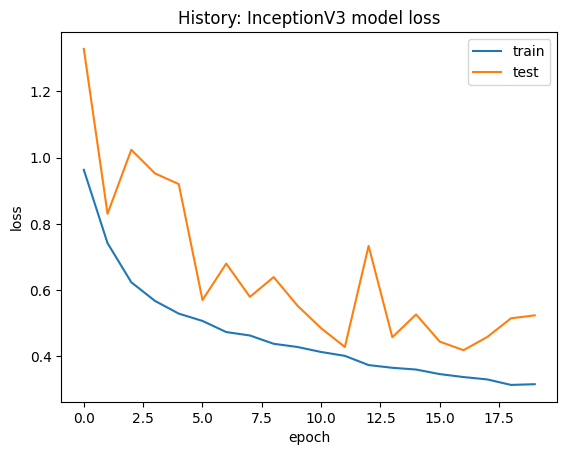

In [ ]:
#Diagaram loss model
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('History: InceptionV3 model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper right')
plt.show()

In [ ]:
#History perkembangan akurasi
hist.history['loss']

[0.9632480144500732,
 0.7418369650840759,
 0.6237456202507019,
 0.5674804449081421,
 0.5291361212730408,
 0.5070775151252747,
 0.4735115170478821,
 0.46307089924812317,
 0.43804752826690674,
 0.42845192551612854,
 0.41330835223197937,
 0.40163344144821167,
 0.373776912689209,
 0.36560314893722534,
 0.36035412549972534,
 0.34652644395828247,
 0.3376234769821167,
 0.330473929643631,
 0.31387415528297424,
 0.31604549288749695]

**Prediksi Data Baru**

13/13 ━━━━━━━━━━━━━━━━━━━━ 15s 654ms/step


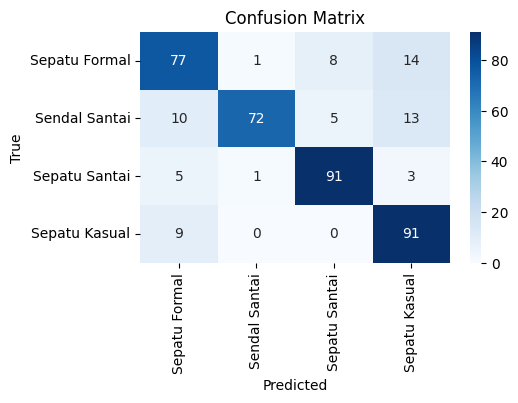

               precision    recall  f1-score   support

Sepatu Formal       0.76      0.77      0.77       100
Sendal Santai       0.97      0.72      0.83       100
Sepatu Santai       0.88      0.91      0.89       100
Sepatu Kasual       0.75      0.91      0.82       100

     accuracy                           0.83       400
    macro avg       0.84      0.83      0.83       400
 weighted avg       0.84      0.83      0.83       400



In [ ]:

import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

# Prediksi kelas dari data validasi
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Membuat confusion matrix
confusion_mtx = confusion_matrix(y_true, y_pred_classes)

# Menampilkan confusion matrix
plt.figure(figsize=(5,3))
import seaborn as sns
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap="Blues", xticklabels=label_decode, yticklabels=label_decode)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Menampilkan laporan klasifikasi
class_names = label_decode
print(classification_report(y_true, y_pred_classes, target_names=class_names))


In [ ]:
tf.keras.backend.clear_session()

#Menyimpan Model
model.save('4 Class InceptionV3 Adam 32-20.h5')